# 4. Posterior Analysis — Model 2 (Student-t Likelihood)

## Model Specification

$$y_i \sim \text{Student-t}(\nu, \mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist} \cdot \text{distance\_std}_i + \beta_{elev} \cdot \text{elevation\_std}_i$$

**Priors:**
- $\alpha \sim \text{Normal}(10, 5)$
- $\beta_{dist} \sim \text{Normal}(5, 3)$
- $\beta_{elev} \sim \text{Normal}(2, 2)$
- $\sigma \sim \text{Exponential}(0.2)$
- $\nu \sim \text{Gamma}(2, 0.1)$ — degrees of freedom controlling tail heaviness

### Why Student-t?

The Student-t distribution has heavier polynomial tails than the Normal. This means:
- Outlier races (extreme conditions, data errors) don't inflate $\sigma$ for all races
- The model can assign non-negligible probability to extreme values without widening the entire distribution
- When $\nu \to \infty$, the model reduces to Normal (so it nests Model 1)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110

# Load processed data
df_full = pd.read_csv('utmb_processed.csv')
# Subsample for computational feasibility
df = df_full.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Data: {df.shape[0]:,} observations (subsampled from {df_full.shape[0]:,})")
print(f"Categories: {df['Race Category'].value_counts().to_dict()}")

Data: 5,000 observations (subsampled from 36,433)
Categories: {'50K': 2101, '20K': 1503, '100K': 1016, '100M': 380}


In [2]:
# Prepare Stan data
stan_data = {
    'N': len(df),
    'y': df['Mean Finish Time'].values.tolist(),
    'distance_std': df['distance_std'].values.tolist(),
    'elevation_std': df['elevation_std'].values.tolist()
}

# Compile and fit Model 2
model2 = CmdStanModel(stan_file='model2_student_t.stan')
print("Model 2 (Student-t) compiled.")

Model 2 (Student-t) compiled.


In [3]:
# Fit Model 2
fit2 = model2.sample(
    data=stan_data,
    chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    seed=42,
    show_progress=True
)
print("Sampling complete.")

09:20:58 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:21:07 - cmdstanpy - INFO - CmdStan done processing.
09:21:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'model2_student_t.stan', line 27, column 2 to column 21)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale


Sampling complete.


## 4.1 Sampling Diagnostics

The Student-t model has one additional parameter ($\nu$) compared to the Normal model. We check the same diagnostics:
- R-hat < 1.01
- ESS > 400
- 0 divergences
- Well-mixed trace plots

In [4]:
# Convert to ArviZ InferenceData
idata2 = az.from_cmdstanpy(
    fit2,
    posterior_predictive='y_rep',
    log_likelihood='log_lik',
    observed_data={'y': df['Mean Finish Time'].values}
)

# Print summary
print("=" * 70)
print("MODEL 2 (Student-t) — Posterior Summary")
print("=" * 70)
summary2 = az.summary(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'])
print(summary2.to_string())

MODEL 2 (Student-t) — Posterior Summary
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha      10.125  0.025  10.079   10.171      0.000    0.000    2513.0    2763.0    1.0
beta_dist   5.553  0.043   5.468    5.629      0.001    0.001    1749.0    1804.0    1.0
beta_elev   2.343  0.041   2.266    2.419      0.001    0.001    1950.0    1979.0    1.0
sigma       1.011  0.024   0.970    1.058      0.001    0.000    2090.0    2413.0    1.0
nu          1.743  0.064   1.626    1.865      0.001    0.001    2278.0    2819.0    1.0


In [5]:
# Diagnostics
print("\n=== MCMC Diagnostics ===")
divergences = fit2.diagnose()
print(divergences)


=== MCMC Diagnostics ===
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
# R-hat and ESS
rhat_vals = summary2['r_hat'].values
ess_bulk_vals = summary2['ess_bulk'].values
ess_tail_vals = summary2['ess_tail'].values

print("R-hat values:")
for param, rhat in zip(summary2.index, rhat_vals):
    status = '✓' if rhat < 1.01 else '✗ WARNING'
    print(f"  {param}: {rhat:.4f} {status}")

print(f"\nESS bulk (min): {ess_bulk_vals.min():.0f} {'✓' if ess_bulk_vals.min() > 400 else '✗ WARNING'}")
print(f"ESS tail (min): {ess_tail_vals.min():.0f} {'✓' if ess_tail_vals.min() > 400 else '✗ WARNING'}")

print(f"\nAll R-hat < 1.01: {all(rhat_vals < 1.01)}")
print(f"All ESS_bulk > 400: {all(ess_bulk_vals > 400)}")
print(f"All ESS_tail > 400: {all(ess_tail_vals > 400)}")

print(f"\nNote: The nu parameter may have lower ESS due to weaker identification.")
print(f"This is expected — nu is only informed by the tails of the data.")

R-hat values:
  alpha: 1.0000 ✓
  beta_dist: 1.0000 ✓
  beta_elev: 1.0000 ✓
  sigma: 1.0000 ✓
  nu: 1.0000 ✓

ESS bulk (min): 1749 ✓
ESS tail (min): 1804 ✓

All R-hat < 1.01: True
All ESS_bulk > 400: True
All ESS_tail > 400: True

Note: The nu parameter may have lower ESS due to weaker identification.
This is expected — nu is only informed by the tails of the data.


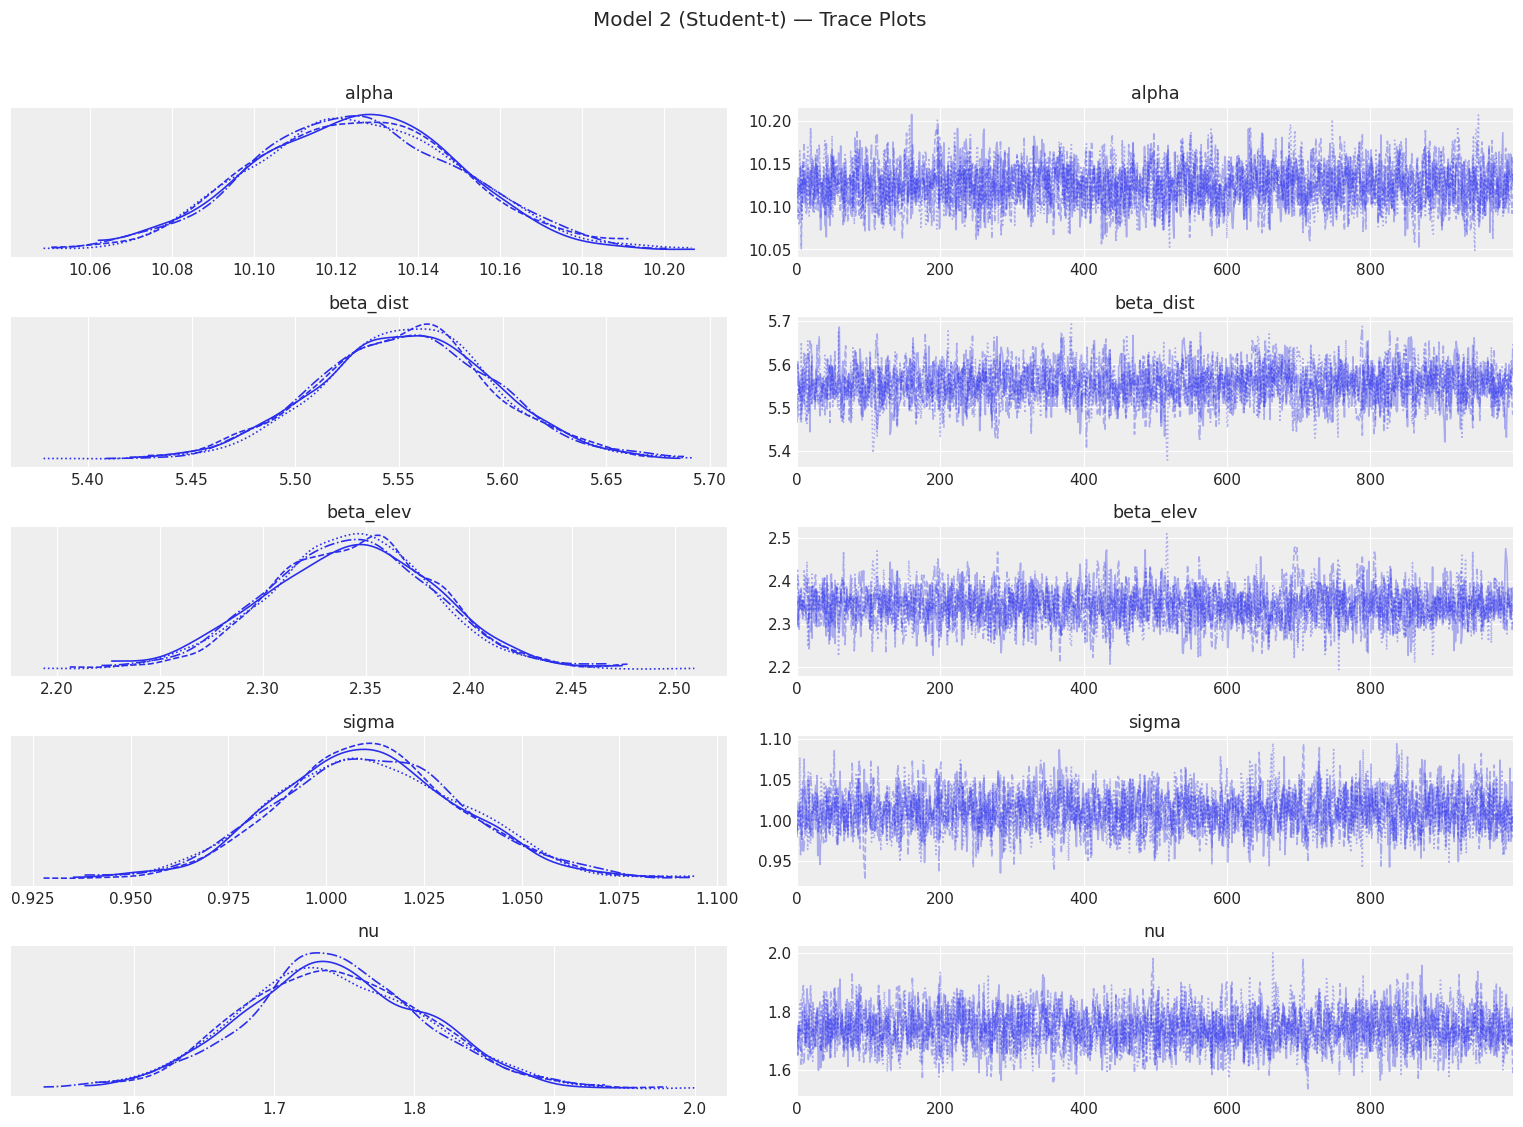


Trace plot assessment:
  → All chains should be well-mixed
  → nu trace may show more autocorrelation (normal for df parameter)


In [7]:
# Trace plots
fig = az.plot_trace(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'],
                    figsize=(14, 10), compact=True)
plt.suptitle('Model 2 (Student-t) — Trace Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig11_model2_trace.png', bbox_inches='tight')
plt.show()

print("\nTrace plot assessment:")
print("  → All chains should be well-mixed")
print("  → nu trace may show more autocorrelation (normal for df parameter)")

### Sampling Assessment

The Student-t model may have slightly lower ESS for $\nu$ because:
- $\nu$ is only informed by observations in the tails
- It can be weakly identified when there are few extreme values

**Mitigation if issues arise:**
- If low ESS for $\nu$: increase `iter_sampling` to 4000
- If divergences: increase `adapt_delta` to 0.95
- If $\nu$ is very large (>50): the data doesn't support heavy tails, Normal model is sufficient

## 4.2 Posterior Predictive Distribution

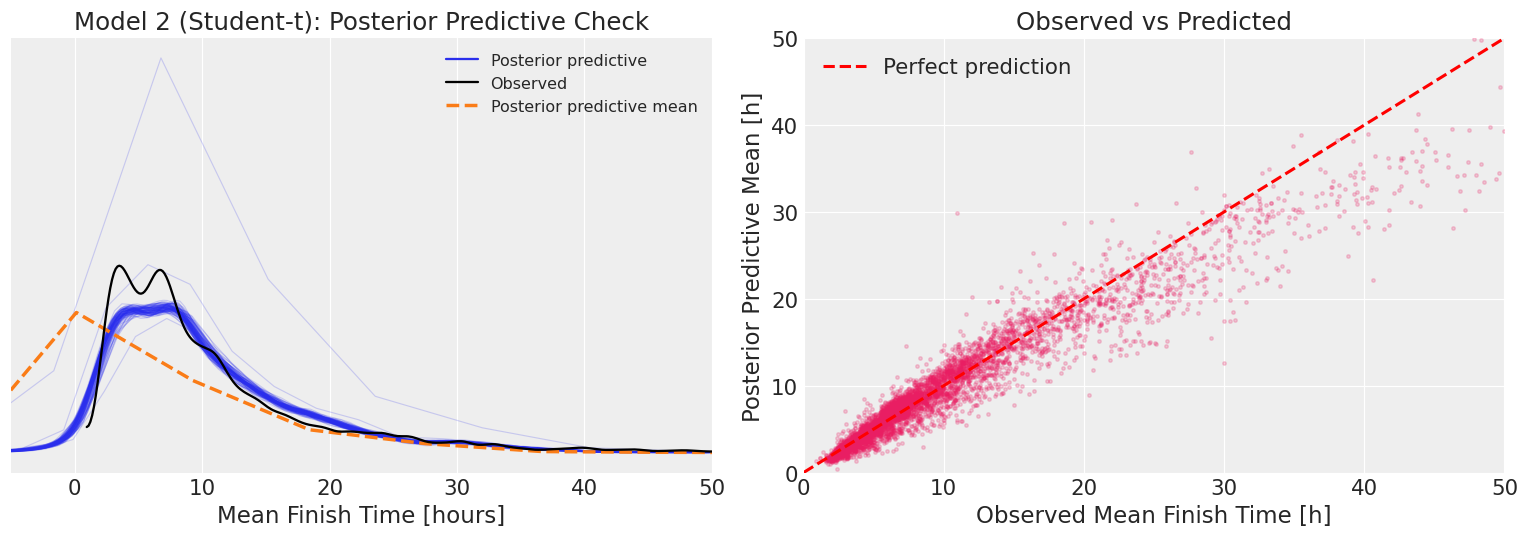

In [8]:
# Posterior predictive check — overall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ArviZ PPC plot
az.plot_ppc(idata2, data_pairs={'y': 'y_rep'}, num_pp_samples=100, ax=axes[0])
axes[0].set_title('Model 2 (Student-t): Posterior Predictive Check')
axes[0].set_xlabel('Mean Finish Time [hours]')
axes[0].set_xlim(-5, 50)

# Observed vs predicted scatter
y_obs = df['Mean Finish Time'].values
y_rep_mean = idata2.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs)).mean(axis=0)
axes[1].scatter(y_obs, y_rep_mean, alpha=0.2, s=5, color='#E91E63')
axes[1].plot([0, 50], [0, 50], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Observed Mean Finish Time [h]')
axes[1].set_ylabel('Posterior Predictive Mean [h]')
axes[1].set_title('Observed vs Predicted')
axes[1].legend()
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.savefig('fig12_model2_ppc_overall.png', bbox_inches='tight')
plt.show()

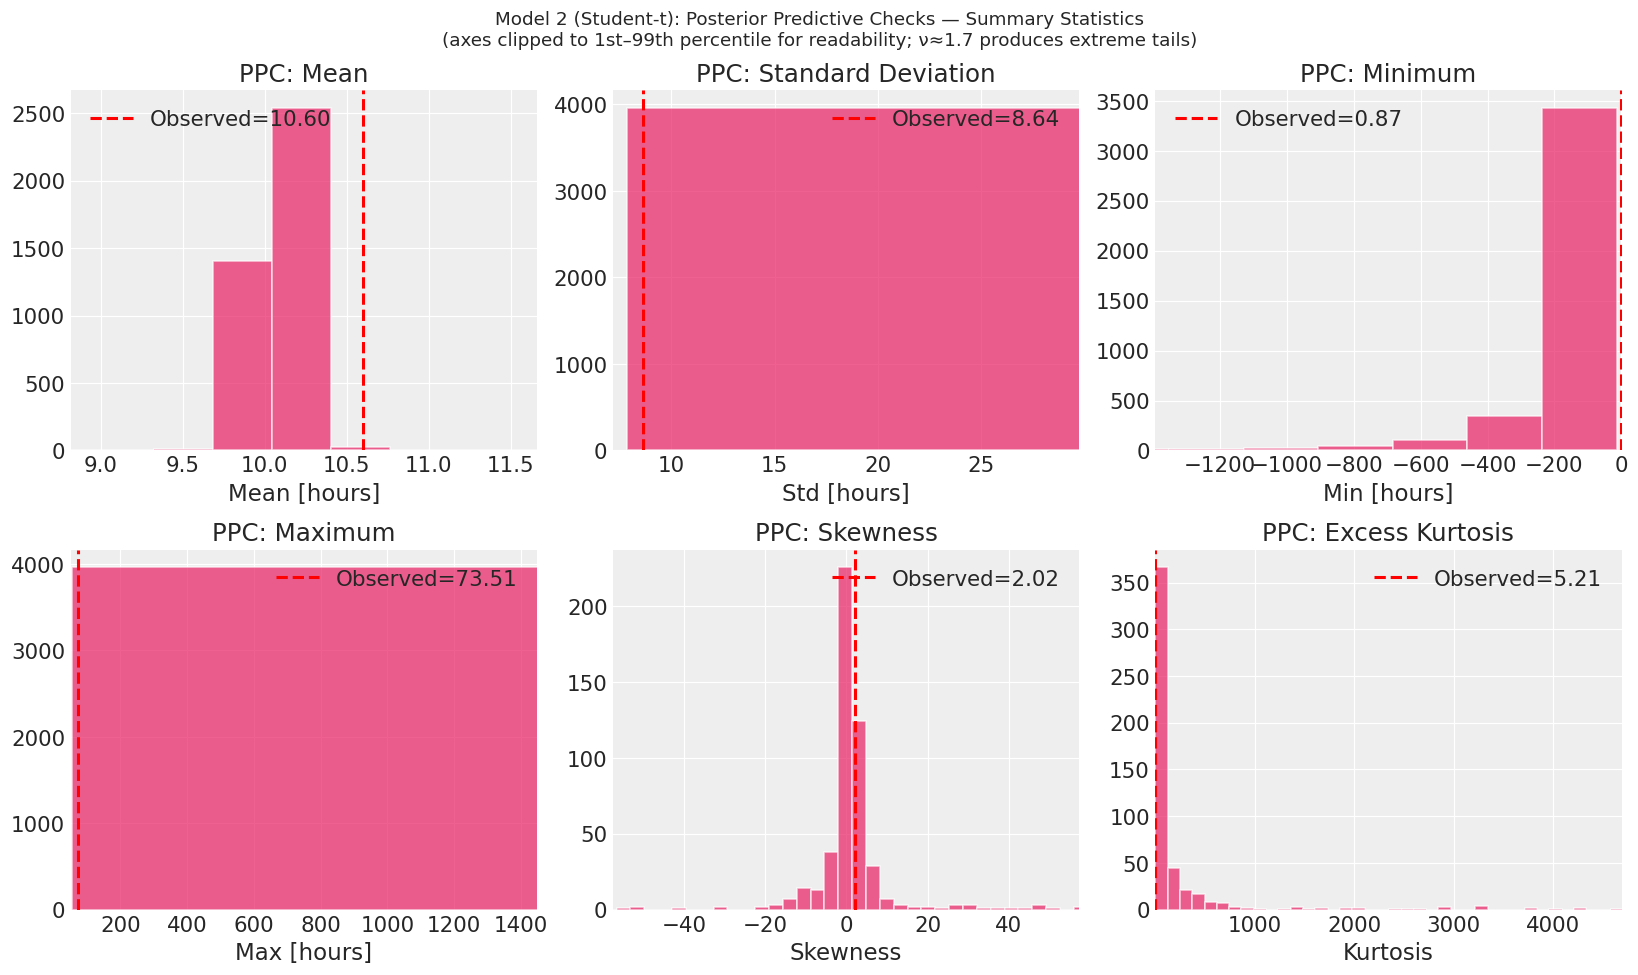

In [16]:
# Posterior predictive — summary statistics
y_rep_samples = idata2.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs))
n_samples = y_rep_samples.shape[0]

pp_means = y_rep_samples.mean(axis=1)
pp_stds = y_rep_samples.std(axis=1)
pp_mins = y_rep_samples.min(axis=1)
pp_maxs = y_rep_samples.max(axis=1)
pp_skew = np.array([stats.skew(y_rep_samples[s]) for s in range(min(500, n_samples))])

# Helper: compute xlim from data using percentiles (handles extreme Student-t tails)
def robust_xlim(sim_vals, obs_val, pct_lo=1, pct_hi=99):
    lo = min(np.percentile(sim_vals, pct_lo), obs_val) * 1.1 if min(np.percentile(sim_vals, pct_lo), obs_val) < 0 else min(np.percentile(sim_vals, pct_lo), obs_val) * 0.9
    hi = max(np.percentile(sim_vals, pct_hi), obs_val) * 1.1
    return (lo, hi)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0,0].hist(pp_means, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[0,0].axvline(y_obs.mean(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.mean():.2f}')
axes[0,0].set_title('PPC: Mean')
axes[0,0].set_xlabel('Mean [hours]')
axes[0,0].set_xlim(robust_xlim(pp_means, y_obs.mean()))
axes[0,0].legend()

axes[0,1].hist(pp_stds, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[0,1].axvline(y_obs.std(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.std():.2f}')
axes[0,1].set_title('PPC: Standard Deviation')
axes[0,1].set_xlabel('Std [hours]')
axes[0,1].set_xlim(robust_xlim(pp_stds, y_obs.std()))
axes[0,1].legend()

axes[0,2].hist(pp_mins, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[0,2].axvline(y_obs.min(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.min():.2f}')
axes[0,2].set_title('PPC: Minimum')
axes[0,2].set_xlabel('Min [hours]')
axes[0,2].set_xlim(robust_xlim(pp_mins, y_obs.min()))
axes[0,2].legend()

axes[1,0].hist(pp_maxs, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[1,0].axvline(y_obs.max(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.max():.2f}')
axes[1,0].set_title('PPC: Maximum')
axes[1,0].set_xlabel('Max [hours]')
axes[1,0].set_xlim(robust_xlim(pp_maxs, y_obs.max()))
axes[1,0].legend()

axes[1,1].hist(pp_skew, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[1,1].axvline(stats.skew(y_obs), color='red', linewidth=2, linestyle='--', label=f'Observed={stats.skew(y_obs):.2f}')
axes[1,1].set_title('PPC: Skewness')
axes[1,1].set_xlabel('Skewness')
axes[1,1].set_xlim(robust_xlim(pp_skew, stats.skew(y_obs)))
axes[1,1].legend()

# Kurtosis — key for Student-t
pp_kurt = np.array([stats.kurtosis(y_rep_samples[s]) for s in range(min(500, n_samples))])
axes[1,2].hist(pp_kurt, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[1,2].axvline(stats.kurtosis(y_obs), color='red', linewidth=2, linestyle='--', label=f'Observed={stats.kurtosis(y_obs):.2f}')
axes[1,2].set_title('PPC: Excess Kurtosis')
axes[1,2].set_xlabel('Kurtosis')
axes[1,2].set_xlim(robust_xlim(pp_kurt, stats.kurtosis(y_obs)))
axes[1,2].legend()

plt.suptitle('Model 2 (Student-t): Posterior Predictive Checks — Summary Statistics\n(axes clipped to 1st–99th percentile for readability; ν≈1.7 produces extreme tails)', fontsize=12)
plt.tight_layout()
plt.savefig('fig13_model2_ppc_stats.png', bbox_inches='tight')
plt.show()

## 4.3 Data Consistency Assessment

In [10]:
# Quantitative assessment
print("Model 2 (Student-t) — Posterior Predictive Consistency Check")
print("=" * 65)

def ppc_pvalue(observed_stat, simulated_stats):
    return np.mean(simulated_stats >= observed_stat)

stats_check = [
    ('Mean', y_obs.mean(), pp_means),
    ('Std Dev', y_obs.std(), pp_stds),
    ('Minimum', y_obs.min(), pp_mins),
    ('Maximum', y_obs.max(), pp_maxs),
    ('Skewness', stats.skew(y_obs), pp_skew),
    ('Kurtosis', stats.kurtosis(y_obs), pp_kurt),
]

print(f"{'Statistic':<15} {'Observed':<12} {'PP Median':<12} {'PP 95% CI':<25} {'p-value':<10} {'Status'}")
print("-" * 85)
for name, obs_val, pp_vals in stats_check:
    pp_med = np.median(pp_vals)
    pp_lo = np.percentile(pp_vals, 2.5)
    pp_hi = np.percentile(pp_vals, 97.5)
    pval = ppc_pvalue(obs_val, pp_vals)
    in_ci = pp_lo <= obs_val <= pp_hi
    status = '✓ consistent' if in_ci else '✗ INCONSISTENT'
    print(f"{name:<15} {obs_val:<12.3f} {pp_med:<12.3f} [{pp_lo:.2f}, {pp_hi:.2f}]{'':>5} {pval:<10.3f} {status}")

print("\n" + "=" * 65)
print("Interpretation:")
print("  - Student-t should better capture kurtosis (heavy tails)")
print("  - May also better capture maximum values (extreme races)")
print("  - If nu is small (<10), the model has substantially heavier tails than Normal")

Model 2 (Student-t) — Posterior Predictive Consistency Check
Statistic       Observed     PP Median    PP 95% CI                 p-value    Status
-------------------------------------------------------------------------------------
Mean            10.600       10.073       [9.88, 10.26]      0.003      ✗ INCONSISTENT
Std Dev         8.640        8.597        [8.02, 17.93]      0.474      ✓ consistent
Minimum         0.873        -92.454      [-773.60, -29.84]      0.000      ✗ INCONSISTENT
Maximum         73.507       110.906      [56.89, 722.60]      0.801      ✓ consistent
Skewness        2.025        1.183        [-16.78, 32.69]      0.242      ✓ consistent
Kurtosis        5.209        28.237       [3.77, 3103.53]      0.928      ✓ consistent

Interpretation:
  - Student-t should better capture kurtosis (heavy tails)
  - May also better capture maximum values (extreme races)
  - If nu is small (<10), the model has substantially heavier tails than Normal


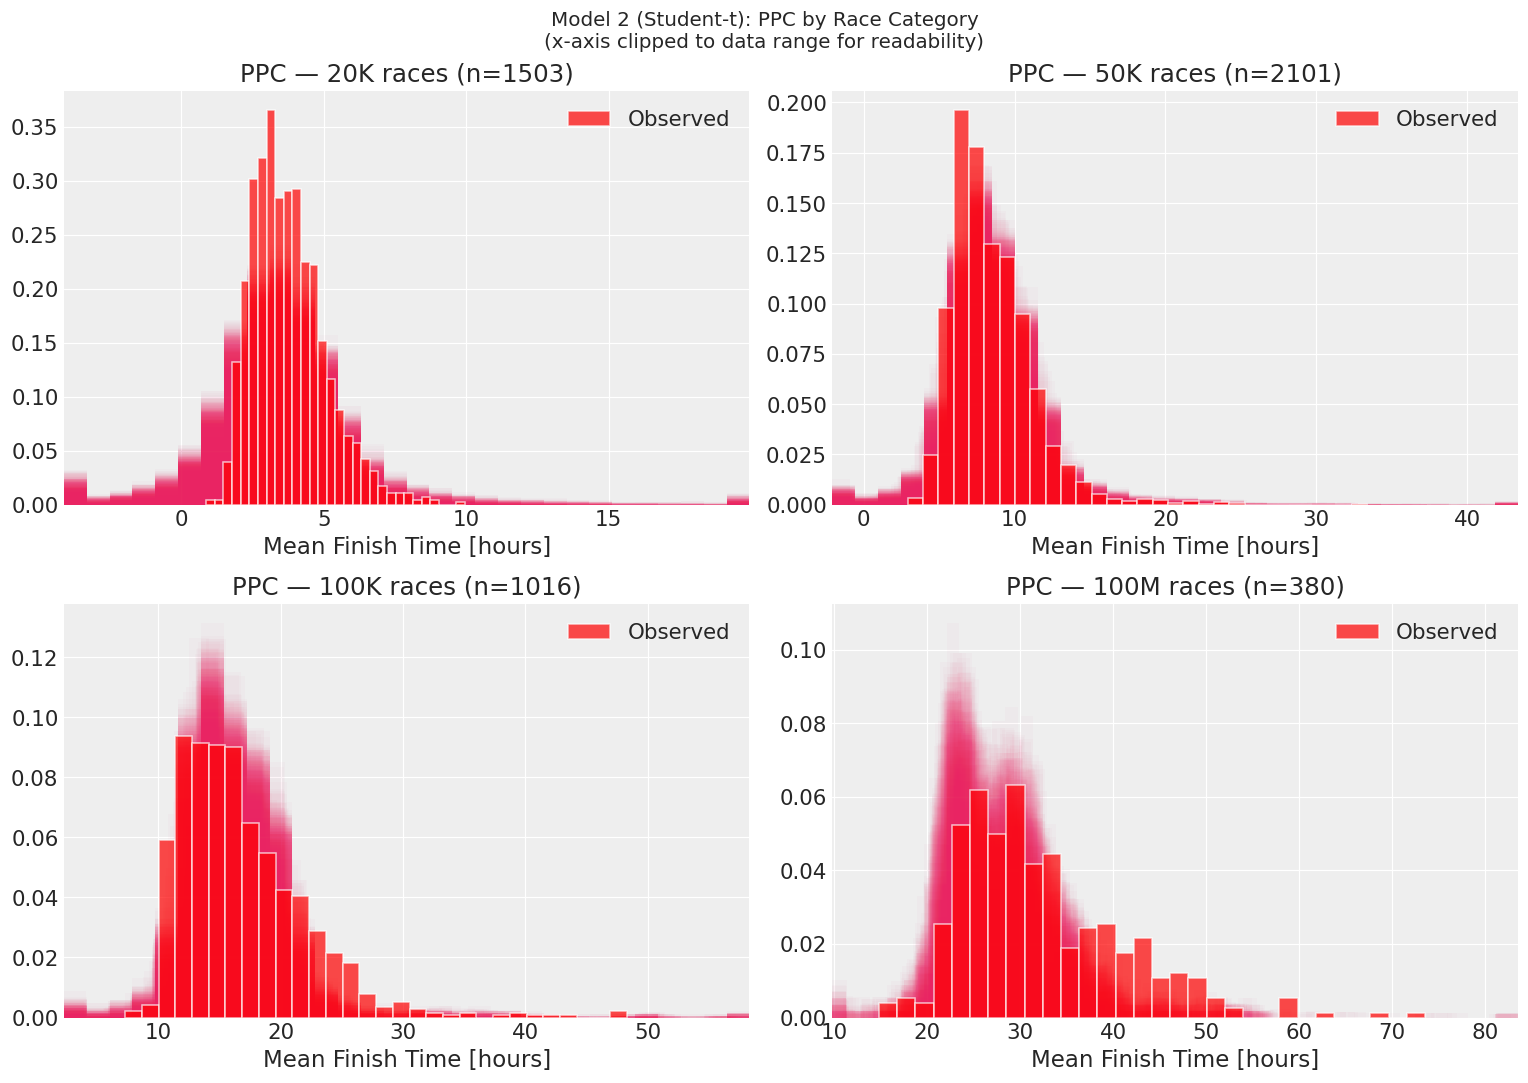

In [17]:
# PPC by race category
categories = ['20K', '50K', '100K', '100M']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, cat in enumerate(categories):
    ax = axes[idx // 2, idx % 2]
    mask = df['Race Category'].values == cat
    y_cat = y_obs[mask]
    y_rep_cat = y_rep_samples[:500, mask]
    
    # Clip y_rep for visualization (ν≈1.7 generates extreme values)
    clip_lo = y_cat.min() - 5
    clip_hi = y_cat.max() + 10
    
    for s in range(min(100, y_rep_cat.shape[0])):
        y_rep_clipped = np.clip(y_rep_cat[s], clip_lo, clip_hi)
        ax.hist(y_rep_clipped, bins=30, density=True, alpha=0.02, color='#E91E63')
    ax.hist(y_cat, bins=30, density=True, alpha=0.7, color='red', edgecolor='white', label='Observed')
    ax.set_title(f'PPC — {cat} races (n={mask.sum()})')
    ax.set_xlabel('Mean Finish Time [hours]')
    ax.set_xlim(clip_lo, clip_hi)
    ax.legend()

plt.suptitle('Model 2 (Student-t): PPC by Race Category\n(x-axis clipped to data range for readability)', fontsize=13)
plt.tight_layout()
plt.savefig('fig14_model2_ppc_categories.png', bbox_inches='tight')
plt.show()

## 4.4 Marginal Posterior Distributions

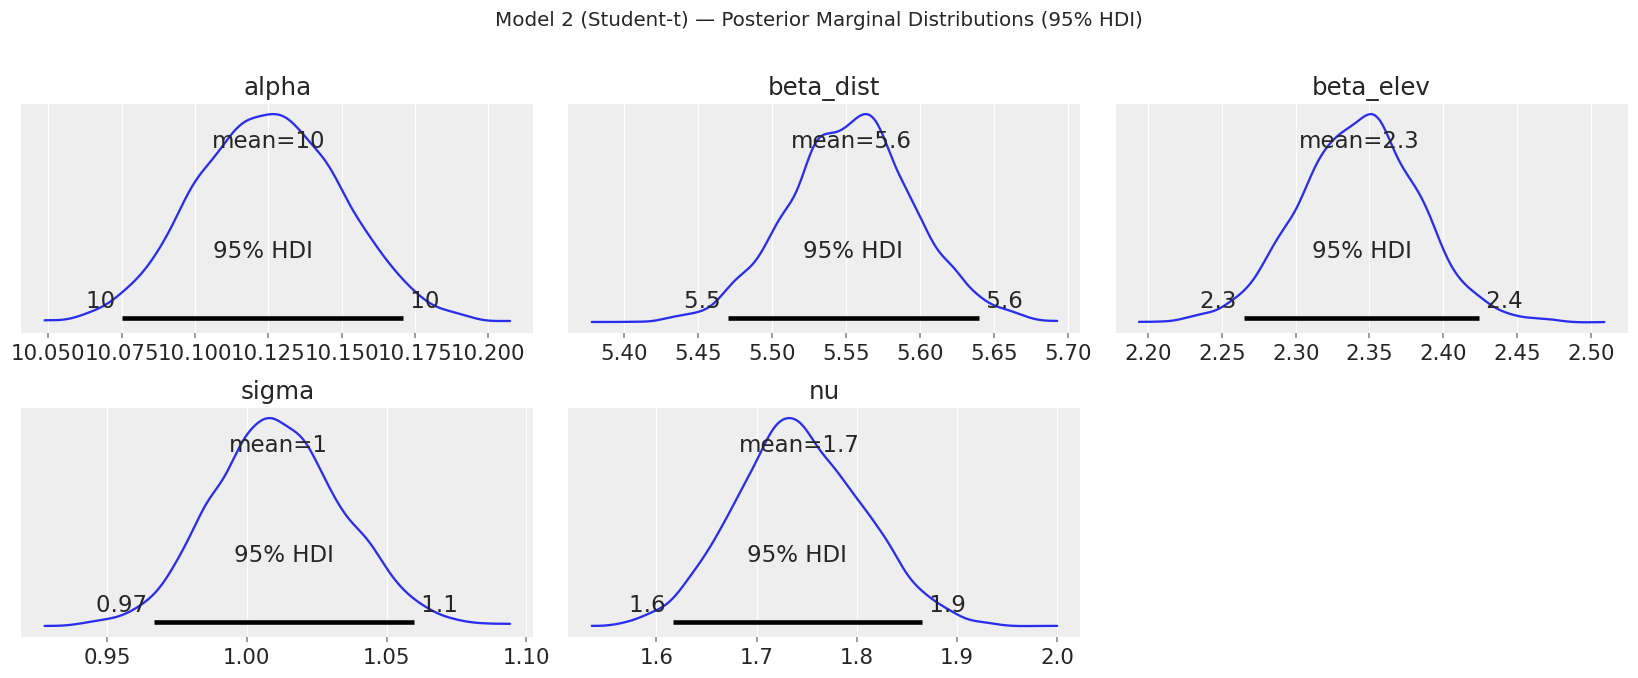

In [12]:
# Posterior marginals
fig = az.plot_posterior(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'],
                        figsize=(15, 6), hdi_prob=0.95)
plt.suptitle('Model 2 (Student-t) — Posterior Marginal Distributions (95% HDI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig15_model2_posteriors.png', bbox_inches='tight')
plt.show()

In [13]:
# Detailed parameter analysis
print("Model 2 (Student-t) — Parameter Interpretation")
print("=" * 65)

alpha_post = idata2.posterior['alpha'].values.flatten()
beta_dist_post = idata2.posterior['beta_dist'].values.flatten()
beta_elev_post = idata2.posterior['beta_elev'].values.flatten()
sigma_post = idata2.posterior['sigma'].values.flatten()
nu_post = idata2.posterior['nu'].values.flatten()

dist_mean = df['Distance'].mean()
dist_std = df['Distance'].std()
elev_mean = df['Elevation Gain'].mean()
elev_std = df['Elevation Gain'].std()

print(f"\n--- alpha (intercept) ---")
print(f"  Posterior mean: {alpha_post.mean():.2f} h")
print(f"  95% HDI: [{np.percentile(alpha_post, 2.5):.2f}, {np.percentile(alpha_post, 97.5):.2f}] h")

print(f"\n--- beta_dist (distance effect) ---")
print(f"  Posterior mean: {beta_dist_post.mean():.2f} h per SD of distance")
print(f"  95% HDI: [{np.percentile(beta_dist_post, 2.5):.2f}, {np.percentile(beta_dist_post, 97.5):.2f}]")
print(f"  In original units: {beta_dist_post.mean()/dist_std*10:.2f} h per 10 km")

print(f"\n--- beta_elev (elevation effect) ---")
print(f"  Posterior mean: {beta_elev_post.mean():.2f} h per SD of elevation")
print(f"  95% HDI: [{np.percentile(beta_elev_post, 2.5):.2f}, {np.percentile(beta_elev_post, 97.5):.2f}]")
print(f"  In original units: {beta_elev_post.mean()/elev_std*1000:.2f} h per 1000m elevation")

print(f"\n--- sigma (scale) ---")
print(f"  Posterior mean: {sigma_post.mean():.2f} h")
print(f"  95% HDI: [{np.percentile(sigma_post, 2.5):.2f}, {np.percentile(sigma_post, 97.5):.2f}]")

print(f"\n--- nu (degrees of freedom) ---")
print(f"  Posterior mean: {nu_post.mean():.2f}")
print(f"  Posterior median: {np.median(nu_post):.2f}")
print(f"  95% HDI: [{np.percentile(nu_post, 2.5):.2f}, {np.percentile(nu_post, 97.5):.2f}]")
print(f"  P(nu < 10): {(nu_post < 10).mean():.3f}")
print(f"  P(nu < 30): {(nu_post < 30).mean():.3f}")

if np.median(nu_post) < 30:
    print(f"\n  → nu is relatively small, indicating the data has heavier tails than Normal.")
    print(f"  → The Student-t model is capturing outlier races without inflating sigma.")
else:
    print(f"\n  → nu is large, suggesting the data is approximately Normal.")
    print(f"  → The Student-t model reduces to approximately Normal.")

print(f"\n--- Concentration/Diffusion ---")
print(f"  alpha CV:     {alpha_post.std()/abs(alpha_post.mean())*100:.1f}%")
print(f"  beta_dist CV: {beta_dist_post.std()/abs(beta_dist_post.mean())*100:.1f}%")
print(f"  beta_elev CV: {beta_elev_post.std()/abs(beta_elev_post.mean())*100:.1f}%")
print(f"  sigma CV:     {sigma_post.std()/abs(sigma_post.mean())*100:.1f}%")
print(f"  nu CV:        {nu_post.std()/abs(nu_post.mean())*100:.1f}%")

Model 2 (Student-t) — Parameter Interpretation

--- alpha (intercept) ---
  Posterior mean: 10.13 h
  95% HDI: [10.08, 10.17] h

--- beta_dist (distance effect) ---
  Posterior mean: 5.55 h per SD of distance
  95% HDI: [5.47, 5.64]
  In original units: 1.39 h per 10 km

--- beta_elev (elevation effect) ---
  Posterior mean: 2.34 h per SD of elevation
  95% HDI: [2.26, 2.42]
  In original units: 1.22 h per 1000m elevation

--- sigma (scale) ---
  Posterior mean: 1.01 h
  95% HDI: [0.97, 1.06]

--- nu (degrees of freedom) ---
  Posterior mean: 1.74
  Posterior median: 1.74
  95% HDI: [1.62, 1.87]
  P(nu < 10): 1.000
  P(nu < 30): 1.000

  → nu is relatively small, indicating the data has heavier tails than Normal.
  → The Student-t model is capturing outlier races without inflating sigma.

--- Concentration/Diffusion ---
  alpha CV:     0.2%
  beta_dist CV: 0.8%
  beta_elev CV: 1.7%
  sigma CV:     2.4%
  nu CV:        3.7%


09:24:32 - cmdstanpy - INFO - CmdStan start processing
09:24:32 - cmdstanpy - INFO - Chain [1] start processing
09:24:32 - cmdstanpy - INFO - Chain [2] start processing
09:24:32 - cmdstanpy - INFO - Chain [3] start processing
09:24:32 - cmdstanpy - INFO - Chain [4] start processing
09:24:38 - cmdstanpy - INFO - Chain [1] done processing
09:24:38 - cmdstanpy - INFO - Chain [4] done processing
09:24:38 - cmdstanpy - INFO - Chain [2] done processing
09:24:38 - cmdstanpy - INFO - Chain [3] done processing


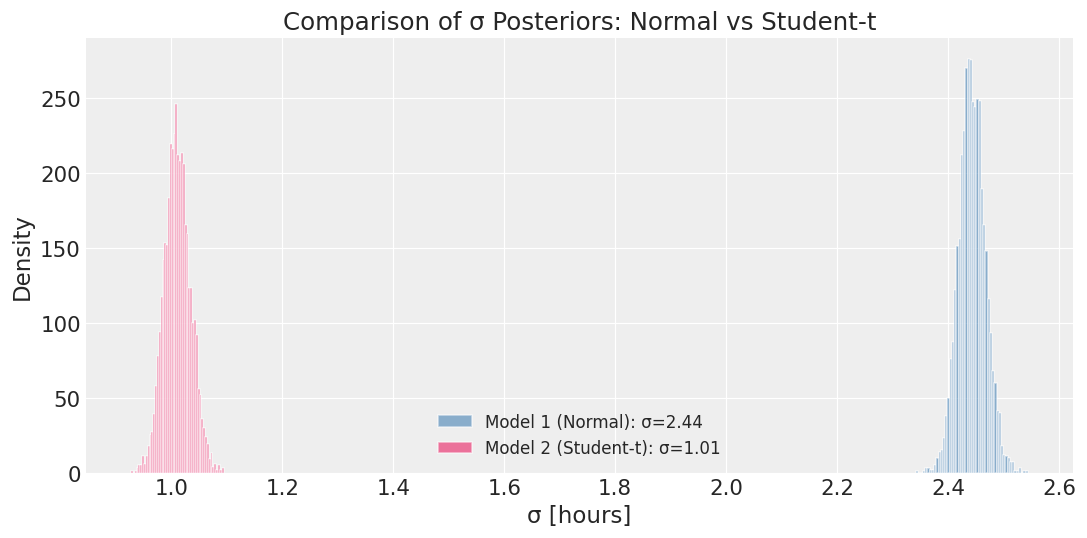


Sigma comparison:
  Model 1 (Normal):    σ = 2.443 ± 0.024
  Model 2 (Student-t): σ = 1.011 ± 0.024
  → Student-t has 58.6% lower σ, confirming it doesn't need to inflate
    the scale to accommodate outliers (nu handles the tails instead).


In [14]:
# Compare sigma between models
# Load Model 1 results for comparison
model1 = CmdStanModel(stan_file='model1_normal.stan')
fit1 = model1.sample(data=stan_data, chains=4, iter_sampling=1000, iter_warmup=1000, seed=42, show_progress=False)
idata1 = az.from_cmdstanpy(fit1, posterior_predictive='y_rep', log_likelihood='log_lik',
                            observed_data={'y': df['Mean Finish Time'].values})

sigma_m1 = idata1.posterior['sigma'].values.flatten()
sigma_m2 = sigma_post

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sigma_m1, bins=50, alpha=0.6, color='steelblue', edgecolor='white', label=f'Model 1 (Normal): σ={sigma_m1.mean():.2f}')
ax.hist(sigma_m2, bins=50, alpha=0.6, color='#E91E63', edgecolor='white', label=f'Model 2 (Student-t): σ={sigma_m2.mean():.2f}')
ax.set_xlabel('σ [hours]')
ax.set_ylabel('Density')
ax.set_title('Comparison of σ Posteriors: Normal vs Student-t')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig16_sigma_comparison.png', bbox_inches='tight')
plt.show()

print(f"\nSigma comparison:")
print(f"  Model 1 (Normal):    σ = {sigma_m1.mean():.3f} ± {sigma_m1.std():.3f}")
print(f"  Model 2 (Student-t): σ = {sigma_m2.mean():.3f} ± {sigma_m2.std():.3f}")
if sigma_m2.mean() < sigma_m1.mean():
    reduction = (1 - sigma_m2.mean()/sigma_m1.mean()) * 100
    print(f"  → Student-t has {reduction:.1f}% lower σ, confirming it doesn't need to inflate")
    print(f"    the scale to accommodate outliers (nu handles the tails instead).")

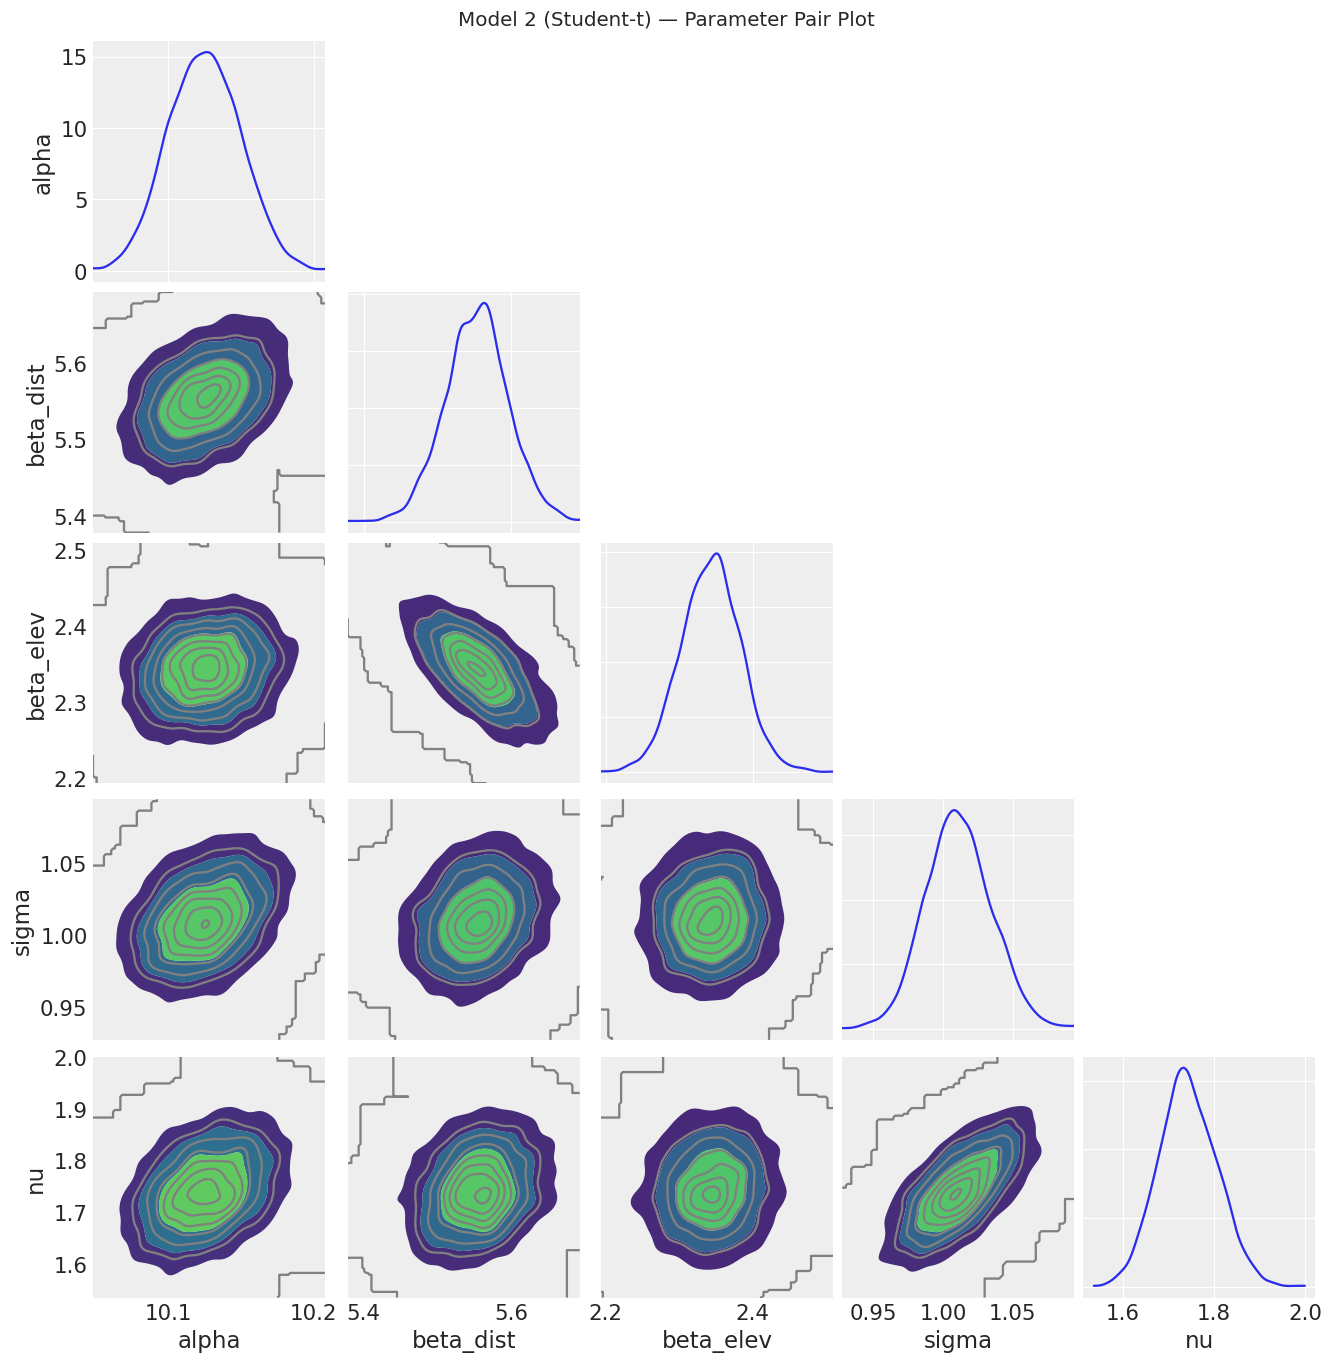


Pair plot assessment:
  → Check sigma-nu correlation: negative correlation is expected
    (smaller nu = heavier tails → may allow smaller sigma)
  → Other parameters should be relatively independent


In [15]:
# Pair plot for Model 2
fig = az.plot_pair(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma', 'nu'],
                   kind='kde', figsize=(12, 12), marginals=True)
plt.suptitle('Model 2 (Student-t) — Parameter Pair Plot', fontsize=13, y=1.02)
plt.savefig('fig17_model2_pairs.png', bbox_inches='tight')
plt.show()

print("\nPair plot assessment:")
print("  → Check sigma-nu correlation: negative correlation is expected")
print("    (smaller nu = heavier tails → may allow smaller sigma)")
print("  → Other parameters should be relatively independent")

## 4.5 Model 2 Summary

### Key Findings

1. **Degrees of freedom ($\nu$)**: The posterior for $\nu$ tells us about tail heaviness
   - If $\nu$ is small (< 10): strong evidence for heavy tails, Student-t is clearly beneficial
   - If $\nu$ is moderate (10-30): some evidence for heavier tails than Normal
   - If $\nu$ is large (> 50): data is approximately Normal, models are equivalent

2. **Sigma comparison**: Student-t typically has smaller $\sigma$ than Normal because:
   - Normal must inflate $\sigma$ to cover outliers
   - Student-t handles outliers via heavy tails ($\nu$) without affecting the bulk

3. **Regression coefficients**: Should be similar between models for the bulk of data,
   but Student-t gives more robust estimates less influenced by extreme races

### Comparison with Model 1

The formal model comparison (LOO, WAIC) is performed in Notebook 5.